In [1]:
#from abc import ABC, abstractmethod
from typing import Optional, List, Type, Tuple, Dict
import math

import numpy as np
from matplotlib import pyplot as plt
from matplotlib.axes._axes import Axes
import torch
import torch.nn as nn
import torch.distributions as D
from torch.func import vmap, jacrev
from tqdm import tqdm
import seaborn as sns
from sklearn.datasets import make_moons, make_circles
from torchvision import datasets, transforms
from torchvision.utils import make_grid

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


# Loader

In [18]:
import pandas as pd

def load_npz_to_dataframe(filename: str, include_targets: bool = True):
    ''' Reconstructs a DataFrame from a saved npz file '''
    data = np.load(filename)
    df = pd.DataFrame(data['features'], columns=data['feature_names'])
    df['targets'] = [t for t in data['targets']]
    
    return df

#poseTraject_df = load_npz_to_dataframe("pose_traject_dataset_2000x50_0.npz")
poseTraject_df = load_npz_to_dataframe("vec_traject_dataset_1M.npz")
poseTraject_df = poseTraject_df.head(200000)
print(poseTraject_df.head())

   s_goal_x  s_goal_y  s_goal_z   v_const     accel  q_init_x  q_init_y  \
0 -1.614258  0.059723       0.0  0.149048  0.028595 -1.385742  0.051270   
1 -1.614258  0.059723       0.0  0.149048  0.028595 -0.722656  0.026733   
2 -1.614258  0.059723       0.0  0.149048  0.028595 -1.051758  0.038910   
3 -1.614258  0.059723       0.0  0.149048  0.028595 -0.279053  0.010330   
4 -1.614258  0.059723       0.0  0.149048  0.028595 -0.777832  0.028778   

   q_init_z  q_init_quatw  q_init_quatx  q_init_quaty  q_init_quatz  \
0       0.0      0.018494           0.0           0.0           1.0   
1       0.0      0.018494           0.0           0.0           1.0   
2       0.0      0.018494           0.0           0.0           1.0   
3       0.0      0.018494           0.0           0.0           1.0   
4       0.0      0.018494           0.0           0.0           1.0   

      t_init  part_enum                                            targets  
0  12.046875        2.0  [[-1.386, 0.05127, 0

c:\Users\acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


In [19]:
# 1. One-hot encode : This creates the 3D one-hot vector part = {Accel, Const, Decel} [2]
part_onehot = pd.get_dummies(poseTraject_df['part_enum'].astype(int), prefix='part').values

# 2. Assemble the final Context Vector C (9 scalars total) [2]
# C = [s_goal_x, s_goal_y, v_const, accel, part_0, part_1, part_2, q_init_x, q_init_y]
C = np.concatenate([
    poseTraject_df[['s_goal_x', 's_goal_y', 'v_const', 'accel']].values,
    part_onehot,
    poseTraject_df[['q_init_x', 'q_init_y']].values
], axis=1)

# 3. Process the Action Vector A (2D trajectories) [1]
# The 'targets' column contains arrays of shape (50, 7) [5]
# We stack them and keep only (x, y) which are indices 0 and 1 [6]
targets_raw = np.stack(poseTraject_df['targets'].values) 
A_2d = targets_raw[:, :, 0:2] # Shape: (batch_size, 50 steps, 2 variables)

# Transpose A for 1D Convolution [batch, channels, length] [3]
# Final shape should be (batch_size, 2, 50)
A = np.transpose(A_2d, (0, 2, 1))

# 4. Prepare PyTorch Tensors for Flow Matching [7]
context_tensor = torch.tensor(C, dtype=torch.float32)
action_tensor = torch.tensor(A, dtype=torch.float32)

# context_tensor: Shape (N, 9) 
# Columns: [s_goal_x, s_goal_y, v_const, accel, part_accel, part_const, part_decel, q_init_x, q_init_y]
# Purpose: Provides physical constraints and the current observed state to guide the flow.

# action_tensor: Shape (N, 2, 50) 
# Channels: [x_pose_sequence, y_pose_sequence]
# Purpose: The target 2D trajectory (50 steps) for the model to learn via Flow Matching.

print(f"Context Vector C (Guided Context) shape: {context_tensor.shape}") # Expected: (N, 9)
print(f"Action Vector A (Trajectory) shape: {action_tensor.shape}")     # Expected: (N, 2, 50)

# print first 5 contexts and actions
print("\nFirst 5 Context Vectors C:")
print(context_tensor[:5])
print("First 5 Action Vectors A:")
print(action_tensor[:5])

Context Vector C (Guided Context) shape: torch.Size([200000, 9])
Action Vector A (Trajectory) shape: torch.Size([200000, 2, 50])

First 5 Context Vectors C:
tensor([[-1.6143,  0.0597,  0.1490,  0.0286,  0.0000,  0.0000,  1.0000, -1.3857,
          0.0513],
        [-1.6143,  0.0597,  0.1490,  0.0286,  0.0000,  1.0000,  0.0000, -0.7227,
          0.0267],
        [-1.6143,  0.0597,  0.1490,  0.0286,  0.0000,  1.0000,  0.0000, -1.0518,
          0.0389],
        [-1.6143,  0.0597,  0.1490,  0.0286,  1.0000,  0.0000,  0.0000, -0.2791,
          0.0103],
        [-1.6143,  0.0597,  0.1490,  0.0286,  0.0000,  1.0000,  0.0000, -0.7778,
          0.0288]])
First 5 Action Vectors A:
tensor([[[-1.3857, -1.3896, -1.3945, -1.3984, -1.4033, -1.4072, -1.4121,
          -1.4160, -1.4209, -1.4248, -1.4287, -1.4326, -1.4365, -1.4404,
          -1.4453, -1.4492, -1.4531, -1.4561, -1.4600, -1.4639, -1.4678,
          -1.4717, -1.4746, -1.4785, -1.4814, -1.4854, -1.4883, -1.4922,
          -1.4951, -1.49

# Model

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class TrajectoryMLP(nn.Module):
    def __init__(self, input_dim=9, hidden_dim=512, output_dim=100):
        super(TrajectoryMLP, self).__init__()
        
        # Architecture: Input(9) -> 512 -> 512 -> 512 -> Output(100)
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(), # Sigmoid Linear Unit (Swish)
            
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),

            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),

            nn.Linear(hidden_dim, 256),
            nn.SiLU(),
            
            nn.Linear(256, output_dim)
        )

    def forward(self, x):
        # x shape: (N, 9)
        return self.network(x)

    def predict_and_reshape(self, context_tensor):
        """
        Helper method to get the trajectory in (2, 50) format for visualization.
        """
        self.eval()
        with torch.no_grad():
            flat_output = self.forward(context_tensor)
            # Reshape from (N, 100) to (N, 2, 50)
            return flat_output.view(-1, 2, 50)

# Train

In [ ]:
# 1. Prepare Data
# Flatten action_tensor from (N, 2, 50) to (N, 100) for MSE regression
targets_flattened = action_tensor.reshape(-1, 100)

dataset = TensorDataset(context_tensor, targets_flattened)
train_loader = DataLoader(dataset, batch_size=256, shuffle=True)

# 2. Initialize Model, Loss, and Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TrajectoryMLP().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_hist = []

# 3. Training Loop
num_epochs = 20 # Adjust based on convergence
print(f"Starting training on {device}...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    loss_hist.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}")

print("Training Complete.")

Starting training on cpu...
Epoch [1/20], Loss: 0.028965
Epoch [2/20], Loss: 0.001136
Epoch [3/20], Loss: 0.000901
Epoch [4/20], Loss: 0.000843
Epoch [5/20], Loss: 0.000871
Epoch [6/20], Loss: 0.000572
Epoch [7/20], Loss: 0.000553
Epoch [8/20], Loss: 0.000582
Epoch [9/20], Loss: 0.000344
Epoch [10/20], Loss: 0.000389
Epoch [11/20], Loss: 0.000468
Epoch [12/20], Loss: 0.000389
Epoch [13/20], Loss: 0.000351
Epoch [14/20], Loss: 0.000311
Epoch [15/20], Loss: 0.000276
Epoch [16/20], Loss: 0.000333
Epoch [17/20], Loss: 0.000306
Epoch [18/20], Loss: 0.000216
Epoch [19/20], Loss: 0.000217
Epoch [20/20], Loss: 0.000470
Training Complete.


In [ ]:
# plot loss curve
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid()(True)
plt.show()

In [8]:
# save the model
model_save_path = 'mlp_traject_model.pth'

# Eval

In [22]:
# Example: Predict on a single sample
sample_context = context_tensor[0:1].to(device) # Shape (1, 9)
predicted_traj = model.predict_and_reshape(sample_context)

# predicted_traj shape: (1, 2, 50)
# Accessing X and Y sequences:
x_coords = predicted_traj[0, 0, :].cpu().numpy()
y_coords = predicted_traj[0, 1, :].cpu().numpy()

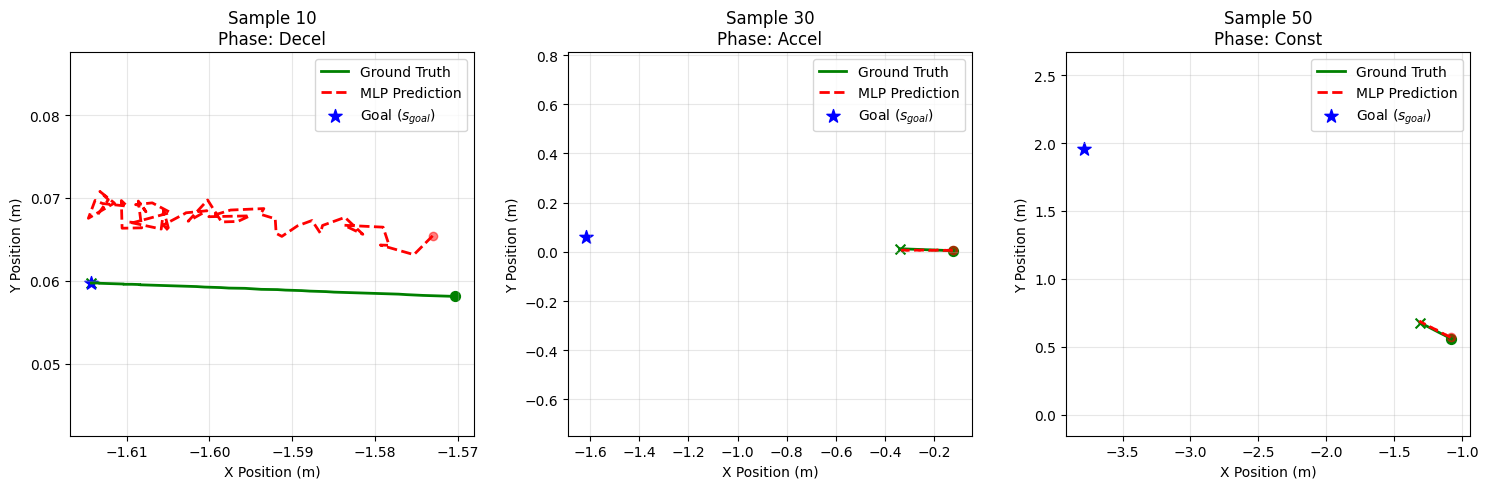

In [35]:
import matplotlib.pyplot as plt
import numpy as np

def evaluate_and_plot(model, context_tensor, action_tensor, num_samples=3):
    """
    Plots the Ground Truth vs. Predicted Trajectories in the XY plane.
    """
    model.eval()
    device = next(model.parameters()).device
    
    # 1. Select random indices for evaluation
    indices = np.random.choice(len(context_tensor), num_samples, replace=False)
    indices = [10, 30, 50] # For consistent evaluation of specific samples
    
    plt.figure(figsize=(15, 5))
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            # Prepare inputs
            context = context_tensor[idx:idx+1].to(device)
            target = action_tensor[idx].cpu().numpy() # Shape (2, 50)
            
            # Forward pass and Reshape
            # Using your previously defined helper method or manual reshape
            prediction_flat = model(context)
            prediction = prediction_flat.view(2, 50).cpu().numpy() # Shape (2, 50)
            
            # 2. Plotting
            plt.subplot(1, num_samples, i + 1)
            
            # Plot Ground Truth (Target)
            plt.plot(target[0, :], target[1, :], 'g-', label='Ground Truth', linewidth=2)
            plt.scatter(target[0, 0], target[1, 0], c='green', marker='o', s=50) # Start
            plt.scatter(target[0, -1], target[1, -1], c='green', marker='x', s=50) # End
            
            # Plot Model Prediction
            plt.plot(prediction[0, :], prediction[1, :], 'r--', label='MLP Prediction', linewidth=2)
            plt.scatter(prediction[0, 0], prediction[1, 0], c='red', marker='o', alpha=0.5)
            
            # Extract s_goal from context (indices 0 and 1) for visual reference
            goal_x, goal_y = context[0, 0].item(), context[0, 1].item()
            plt.scatter(goal_x, goal_y, c='blue', marker='*', s=100, label='Goal ($s_{goal}$)')
            
            plt.title(f"Sample {idx}\nPhase: {get_phase_name(context)}")
            plt.xlabel("X Position (m)")
            plt.ylabel("Y Position (m)")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.axis('equal')

    plt.tight_layout()
    plt.show()

def get_phase_name(context):
    """Helper to identify phase from one-hot encoding [part_0, part_1, part_2]"""
    # Phase indices in your C vector are 4, 5, 6
    phase_vec = context[0, 4:7].cpu().numpy()
    phases = ["Accel", "Const", "Decel"]
    return phases[np.argmax(phase_vec)]

# Execute Evaluation
evaluate_and_plot(model, context_tensor, action_tensor, num_samples=3)

In [25]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import torch

def print_context_params(context_tensor):
    """
    Parses and prints the 9-scalar context vector in a human-readable format.
    C = [s_goal_x, s_goal_y, v_const, accel, part_0, part_1, part_2, q_init_x, q_init_y]
    """
    c = context_tensor.cpu().numpy()
    phases = ["Acceleration", "Constant Velocity", "Deceleration"]
    phase_idx = np.argmax(c[4:7])
    
    print("--- Context Parameters ---")
    print(f"Target Goal (s_goal):  ({c[0]:.4f}, {c[1]:.4f})")
    print(f"Initial Pose (q_init): ({c[7]:.4f}, {c[8]:.4f})")
    print(f"Physical Limits:       v_const={c[2]:.4f}, accel={c[3]:.4f}")
    print(f"Trajectory Phase:      {phases[phase_idx]}")
    print("--------------------------")

def plot_traject_3d(ax, traject, label, color, linestyle='-'):
    """
    Plots a (2, 50) trajectory in 3D space-time (X, Y, Timestep).
    """
    # Create timesteps from 0 to 49
    timesteps = np.arange(traject.shape[1]) 
    
    x = traject[0, :]
    y = traject[1, :]
    
    ax.plot(x, y, timesteps, label=label, color=color, linestyle=linestyle, linewidth=2)
    # Mark start and end
    ax.scatter(x[0], y[0], timesteps[0], color=color, s=20)
    ax.scatter(x[-1], y[-1], timesteps[-1], color=color, marker='x', s=30)

Evaluating Sample Index: 10
--- Context Parameters ---
Target Goal (s_goal):  (-1.6143, 0.0597)
Initial Pose (q_init): (-1.5703, 0.0581)
Physical Limits:       v_const=0.1490, accel=0.0286
Trajectory Phase:      Deceleration
--------------------------


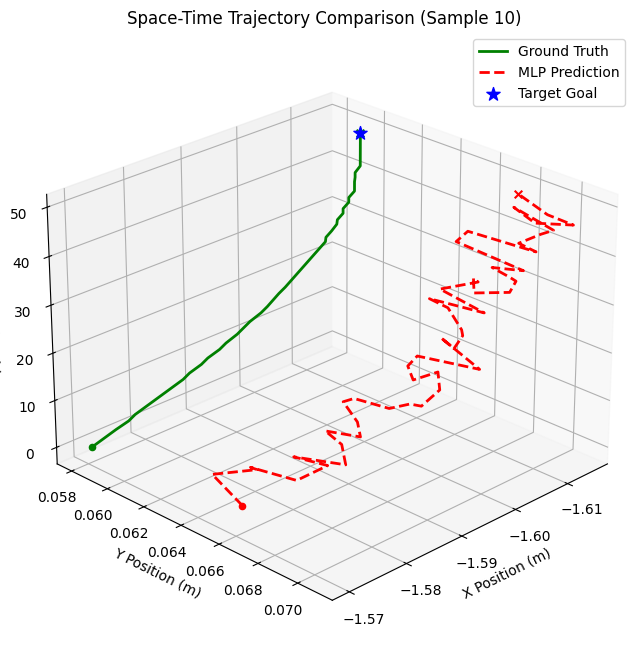

Evaluating Sample Index: 30
--- Context Parameters ---
Target Goal (s_goal):  (-1.6143, 0.0597)
Initial Pose (q_init): (-0.1225, 0.0045)
Physical Limits:       v_const=0.1490, accel=0.0286
Trajectory Phase:      Acceleration
--------------------------


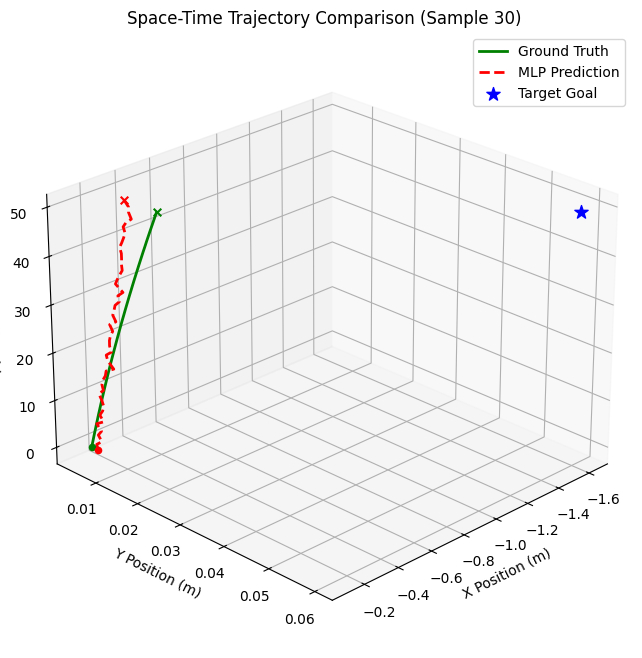

Evaluating Sample Index: 50
--- Context Parameters ---
Target Goal (s_goal):  (-3.7812, 1.9561)
Initial Pose (q_init): (-1.0781, 0.5581)
Physical Limits:       v_const=0.1324, accel=0.0292
Trajectory Phase:      Constant Velocity
--------------------------


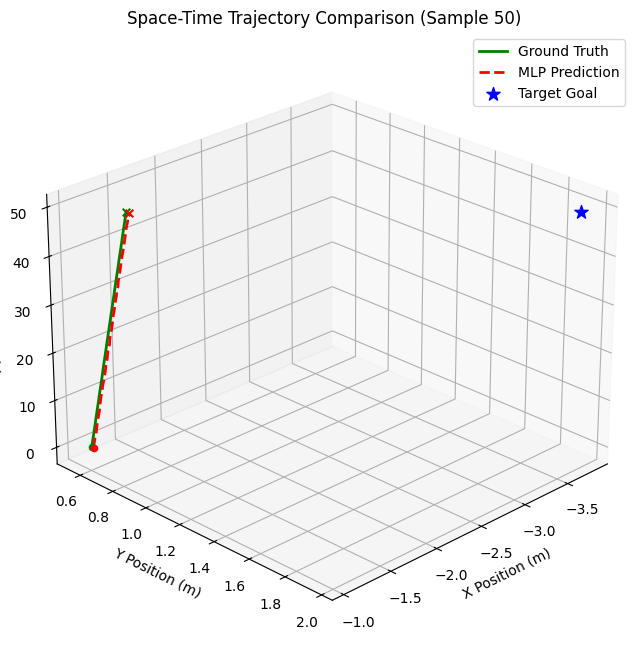

In [36]:
def evaluate_sample_3d(model, context_tensor, action_tensor, sample_idx=None):
    if sample_idx is None:
        sample_idx = np.random.randint(len(context_tensor))
    
    device = next(model.parameters()).device
    model.eval()
    
    # Prepare Data
    context = context_tensor[sample_idx:sample_idx+1].to(device)
    target = action_tensor[sample_idx].cpu().numpy() # (2, 50)
    
    with torch.no_grad():
        prediction_flat = model(context)
        prediction = prediction_flat.view(2, 50).cpu().numpy()
    
    # 1. Print Parameters
    print(f"Evaluating Sample Index: {sample_idx}")
    print_context_params(context[0])
    
    # 2. Setup Plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # 3. Plot both trajectories
    plot_traject_3d(ax, target, label='Ground Truth', color='green')
    plot_traject_3d(ax, prediction, label='MLP Prediction', color='red', linestyle='--')
    
    # Add Goal Marker at the final timestep
    goal_x, goal_y = context[0, 0].item(), context[0, 1].item()
    ax.scatter(goal_x, goal_y, 49, color='blue', marker='*', s=100, label='Target Goal')
    
    # Labels
    ax.set_xlabel('X Position (m)')
    ax.set_ylabel('Y Position (m)')
    ax.set_zlabel('Timestep (t)')
    ax.set_title(f'Space-Time Trajectory Comparison (Sample {sample_idx})')
    ax.legend()
    
    # Optimization for viewing
    ax.view_init(elev=25, azim=45)
    plt.show()

# Run the evaluation
evaluate_sample_3d(model, context_tensor, action_tensor, sample_idx=10)
evaluate_sample_3d(model, context_tensor, action_tensor, sample_idx=30)
evaluate_sample_3d(model, context_tensor, action_tensor, sample_idx=50)